### TELECOM INFRASTRUCTURE ANALYSIS
CELL TOWER/BASE STATION LOCATIONS, NETWORK COVERAGE BY STATE, SIGNAL STRENGTH DATA.


The big question: Where is Nigeria's mobile network infrastructure concentrated, 
who's building it, and how modern is it?

That breaks into three specific questions my dataset can actually answer:

`1. Geographic concentration — Which states/regions have the most cell towers, 
and which look thin on infrastructure?`

`2. Operator footprint — Which network (MTN, Airtel, Glo, 9mobile) has the biggest infrastructure presence overall
and does that change by region?` 

`3.Technology generation gap — What's the GSM (2G) vs UMTS (3G) vs LTE (4G) mix per state/region?`

`4. Coverage range (Average range by region) - A function that flags region where average range exceeds a threshold;
indicating likely rural or urban cities.`



##### Known Limitations / Notes		
- State/region assignment uses the nearest state-capital centroid as a proxy for each state's location.
Towers located near state borders may be assigned to a neighboring state. 
This is a known approximation, not a true GIS spatial join against state boundary polygons.		
- The "unit", "changeable", and "averageSignal" columns are constant across every row in this dataset
 (not populated by OpenCelliD for Nigeria) - retained for completeness but carry no analytical value here.		
- 3 records have a net code (0 or 3) that does not match a known Nigerian operator and are labeled "Unknown/Other".		
- Data reflects cell towers observed by OpenCelliD contributors; 
it is crowd-sourced and may not capture every physical tower, especially in less-trafficked areas.		



### Nigeria Telecom Infrastructure Dataset — Data Dictionary & Summary		
#### Source: OpenCelliD (MCC 621 = Nigeria). State/Region assigned via nearest state-capital centroid approximation.		
		
		
| Column	    | Description |
|---------------|----------------------------------------|
| radio	        | Network technology recorded by OpenCelliD: GSM, UMTS, or LTE. |	
| generation	| Simplified network generation derived from radio (GSM=2G, UMTS=3G, LTE=4G). |	
| mcc	        | Mobile Country Code. 621 = Nigeria for every row in this dataset. |	
| net	        | Mobile Network Code (raw operator identifier reported by OpenCelliD). |	
| operator	    | Network operator name, decoded from net (20=Airtel, 30=MTN, 50=Globacom/Glo, 60=9mobile). |	
| area	        | Location Area Code (LAC) - groups cells into a location area for the network. | 	
| cell	        | Cell ID - unique identifier for this specific cell/sector. |	
| lon		    | Longitude of the cell tower (decimal degrees). |	
| lat		    | Latitude of the cell tower (decimal degrees). |	
| state		    | Nigerian state assigned to this tower via nearest-centroid approximation (see Limitations). |	
| region		| Geopolitical zone of the assigned state (North Central, North East, North West, South East, South South, South West). |	
| range		    | Estimated coverage radius of the cell, in meters. |	
| samples		| Number of measurements OpenCelliD used to estimate this cell position. |	
| unit		    | Internal OpenCelliD field. Constant 0 across this dataset - not used. |	
| changeable	| 1 = position is an estimate that may change over time. Constant 1 across this dataset. |	
| created_date	| Date this cell was first observed by OpenCelliD (converted from Unix timestamp). |	
| updated_date	| Date this cell was last observed/updated by OpenCelliD (converted from Unix timestamp). |	


##### Code Mappings		
Network Operator Codes (net -> operator)		
| net code	| Operator
| ----------| ------------
| 20		| Airtel	
| 30		| MTN	
| 50		| Globacom (Glo)	
| 60		| 9mobile	
| 0 or 3	| Unknown/Other (3 records total - likely test/erroneous entries)	
		
##### Network Generation (radio -> generation)		
| radio	| generation
| ------|----------- 
| GSM	| 2G	
| UMTS	| 3G	
| LTE	| 4G	
		
##### Geopolitical Zones (region) and their States		
| Region		| States included
| --------------| -------------------	
| North Central	| Benue, Federal Capital Territory, Kogi, Kwara, Nasarawa, Niger, Plateau	
| North East	| Adamawa, Bauchi, Borno, Gombe, Taraba, Yobe	
| North West	| Jigawa, Kaduna, Kano, Katsina, Kebbi, Sokoto, Zamfara	
| South East	| Abia, Anambra, Ebonyi, Enugu, Imo	
| South South	| Akwa Ibom, Bayelsa, Cross River, Delta, Edo, Rivers	
| South West	| Ekiti, Lagos, Ogun, Ondo, Osun, Oyo	
		
##### Dataset Summary		
| Metric			| Value	
| ------------------| ----------
| Total tower records	| 999
| Earliest created_date	| 2015-01-09	
| Latest updated_date	| 2026-06-13	

		

### Importing Libraries

In [1]:
## rcParams is a matplot dictionary that applies these settings to every chart after plotting.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Loading the Data

In [3]:
df = pd.read_csv(r"C:\Users\PC\Desktop\FAVE\DATA ANALYSIS\PRESENTATION\telecom_dataset.csv")
df

,radio,generation,mcc,net,operator,area,cell,lon,lat,state,region,range,samples,unit,changeable,created_date,updated_date,average_signal
0,GSM,2G,621,30,MTN,34523,63762,4.5833,8.4691,Kwara,North Central,1724,17,-1,1,02/05/2024,12/06/2026,0
1,GSM,2G,621,30,MTN,22929,24317,3.3659,7.1751,Ogun,South West,1000,2,-1,1,07/04/2026,17/04/2026,0
2,GSM,2G,621,30,MTN,12627,3995,7.5778,6.4737,Enugu,South East,7660,26,-1,1,08/01/2024,06/05/2026,0
3,GSM,2G,621,30,MTN,24921,37217,3.3474,6.5093,Lagos,South West,1000,22,-1,1,21/02/2023,19/04/2026,0
4,GSM,2G,621,30,MTN,42129,22296,7.4108,9.0540,Federal Capital Territory,North Central,1506,19,-1,1,22/07/2023,21/05/2026,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GSM,2G,621,20,Airtel,618,30004,7.3641,5.1078,Rivers,South South,1000,16,-1,1,22/06/2024,24/04/2026,0
996,GSM,2G,621,50,Globacom (Glo),30312,10067,4.9552,9.2475,Kwara,North Central,6613,26,-1,1,10/05/2024,11/04/2026,0
997,GSM,2G,621,30,MTN,12729,19062,10.3138,12.2875,Jigawa,North West,19307,25,-1,1,13/11/2023,26/05/2026,0
998,GSM,2G,621,30,MTN,10222,22532,6.8407,5.1422,Rivers,South South,3209,8,-1,1,03/09/2025,16/03/2026,0


### Data Inspection

In [4]:
print('No. of Rows: ', df.shape[0])

No. of Rows:  1000


In [5]:
print('No. of Columns: ', df.shape[1])

No. of Columns:  18


In [4]:
df = df[df['operator'] !='Unknown/Other']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   radio           1000 non-null   str    
 1   generation      1000 non-null   str    
 2   mcc             1000 non-null   int64  
 3   net             1000 non-null   int64  
 4   operator        1000 non-null   str    
 5   area            1000 non-null   int64  
 6   cell            1000 non-null   int64  
 7   lon             1000 non-null   float64
 8   lat             1000 non-null   float64
 9   state           1000 non-null   str    
 10  region          1000 non-null   str    
 11  range           1000 non-null   int64  
 12  samples         1000 non-null   int64  
 13  unit            1000 non-null   int64  
 14  changeable      1000 non-null   int64  
 15  created_date    1000 non-null   str    
 16  updated_date    1000 non-null   str    
 17  average_signal  1000 non-null   int64  
dtype

In [17]:
df.isnull().sum()

radio             0
generation        0
mcc               0
net               0
operator          0
area              0
cell              0
lon               0
lat               0
state             0
region            0
range             0
samples           0
unit              0
changeable        0
created_date      0
updated_date      0
average_signal    0
dtype: int64

### Fixing Date Column

In [13]:
df['created_date'] = pd.to_datetime(df['created_date'], dayfirst=True)
df['updated_date'] = pd.to_datetime(df['created_date'], dayfirst=True)

### Data Types

In [14]:
df.dtypes

radio                        str
generation                   str
mcc                        int64
net                        int64
operator                     str
area                       int64
cell                       int64
lon                      float64
lat                      float64
state                        str
region                       str
range                      int64
samples                    int64
unit                       int64
changeable                 int64
created_date      datetime64[us]
updated_date      datetime64[us]
average_signal             int64
dtype: object

In [15]:
df.describe()

,mcc,net,area,cell,lon,lat,range,samples,unit,changeable,created_date,updated_date,average_signal
count,1000.0,1000.000000,1000.0000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000,1000,1000.0
mean,621.0,32.266000,21379.2360,6.008245e+06,6.434035,7.760333,2746.699000,11.354000,6.697000,1.0,2024-01-26 13:00:28.800000,2024-01-26 13:00:28.800000,0.0
min,621.0,0.000000,34.0000,1.600000e+01,2.896800,4.660900,500.000000,1.000000,-1.000000,1.0,2015-01-09 00:00:00,2015-01-09 00:00:00,0.0
25%,621.0,30.000000,10723.0000,1.175750e+04,4.498525,6.360900,1000.000000,2.000000,-1.000000,1.0,2023-05-31 00:00:00,2023-05-31 00:00:00,0.0
50%,621.0,30.000000,21040.0000,3.019550e+04,6.915600,7.160050,1475.500000,8.000000,-1.000000,1.0,2024-07-13 00:00:00,2024-07-13 00:00:00,0.0
75%,621.0,30.000000,30340.0000,4.950700e+04,7.530250,9.054025,3221.500000,21.000000,-1.000000,1.0,2025-06-19 00:00:00,2025-06-19 00:00:00,0.0
max,621.0,60.000000,63225.0000,2.320502e+08,13.275200,13.065200,25146.000000,50.000000,509.000000,1.0,2026-06-11 00:00:00,2026-06-11 00:00:00,0.0
std,0.0,10.461007,15730.8316,2.909277e+07,2.167059,2.075959,2996.845902,9.374891,50.804215,0.0,NaN,NaN,0.0


## Towers By Region

In [15]:
## reset_index() is to push the column to be a proper column instead of an index
region_counts = df.groupby('region')['cell'].count().sort_values(ascending=False).reset_index()
region_counts.columns = ['region', 'tower_count']
print(region_counts)

          region  tower_count
0     South West          282
1  North Central          231
2    South South          198
3     South East          120
4     North West          119
5     North East           50


## Towers By State

In [26]:
state_counts = df.groupby('state')['cell'].count().sort_values(ascending=False).reset_index()
state_counts.columns = ['state', 'tower_count']
print(state_counts.head(16))

                        state  tower_count
0                       Lagos          132
1   Federal Capital Territory          115
2                         Oyo           59
3                         Edo           57
4                      Rivers           45
5                       Enugu           44
6                       Delta           42
7                        Kano           39
8                        Ogun           36
9                     Plateau           29
10                     Kaduna           27
11                       Abia           27
12                      Kwara           26
13                    Adamawa           26
14                      Niger           26
15                       Ondo           23


## Operator footprint: Determining Which network (MTN, Airtel, Glo, 9mobile) has the biggest infrastructure presence and in which region.
### That is, for each region, how many towers does each operator have??

In [29]:
operator_region = df.groupby(['region', 'operator'])['cell'].count()
print (operator_region)

region         operator      
North Central  9mobile             3
               Airtel             55
               Globacom (Glo)     50
               MTN               122
               Unknown/Other       1
North East     9mobile             2
               Airtel             11
               Globacom (Glo)      9
               MTN                28
North West     9mobile             8
               Airtel             32
               Globacom (Glo)      9
               MTN                70
South East     9mobile             2
               Airtel             25
               Globacom (Glo)     15
               MTN                76
               Unknown/Other       2
South South    9mobile             5
               Airtel             33
               Globacom (Glo)     37
               MTN               123
South West     9mobile            17
               Airtel             24
               Globacom (Glo)     32
               MTN               209
Name: ce

In [5]:
### fill_value = 0 means replace value to be 0 instead of blank
#### Unstack converts  values to column headers
operator_region = df.groupby(['region', 'operator'])['cell'].count().unstack(fill_value=0)
print (operator_region)

operator       9mobile  Airtel  Globacom (Glo)  MTN
region                                             
North Central        3      55              50  122
North East           2      11               9   28
North West           8      32               9   70
South East           2      25              15   76
South South          5      33              37  123
South West          17      24              32  209


## Technology generation gap 
### For each region, what percentage of towers are 2G, 3G or 4G?

In [5]:
## Grouping by region and generation
### fill_value = 0 means replace value to be 0 instead of blank
#### Unstack converts  values to column headers
gen_region = df.groupby(['region', 'generation'])['cell'].count().unstack(fill_value=0)
print(gen_region)

generation      2G  3G  4G
region                    
North Central  177  21  33
North East      38  10   2
North West     114   3   2
South East     100   7  13
South South    176   9  13
South West     280   0   2


In [6]:
## Calculating the percentages...
### axis=1 tells python to sum across all columns- left to right
gen_region['total'] = gen_region.sum(axis=1)
for gen in ['2G', '3G', '4G']:
    gen_region[f'{gen}_%'] = (gen_region[gen] / gen_region['total'] * 100).round(1)
print(gen_region)

generation      2G  3G  4G  total  2G_%  3G_%  4G_%
region                                             
North Central  177  21  33    231  76.6   9.1  14.3
North East      38  10   2     50  76.0  20.0   4.0
North West     114   3   2    119  95.8   2.5   1.7
South East     100   7  13    120  83.3   5.8  10.8
South South    176   9  13    198  88.9   4.5   6.6
South West     280   0   2    282  99.3   0.0   0.7


In [41]:
print(gen_region[['2G', '3G', '4G','2G_%', '3G_%', '4G_%']])

generation      2G  3G  4G  2G_%  3G_%  4G_%
region                                      
North Central  177  21  33  38.3   4.5   7.1
North East      38  10   2  38.0  10.0   2.0
North West     114   3   2  47.9   1.3   0.8
South East     100   7  13  41.7   2.9   5.4
South South    176   9  13  44.4   2.3   3.3
South West     280   0   2  49.6   0.0   0.4


## Operator vs. Generation cross tab
### Which operator  uses 4G and which uses mostly 2G?

In [45]:
gen_op = df.groupby(['operator', 'generation'])['cell'].count().unstack(fill_value=0)
gen_op['total'] = gen_op.sum(axis=1)
for gen in ['2G', '3G', '4G']:
    gen_op[f'{gen}_%'] = (gen_op[gen] / gen_op['total'] * 100).round(1)
print(gen_op[['2G', '3G', '4G','2G_%', '3G_%', '4G_%']])

generation       2G  3G  4G   2G_%  3G_%  4G_%
operator                                      
9mobile          37   0   0  100.0   0.0   0.0
Airtel          141  16  23   78.3   8.9  12.8
Globacom (Glo)  116  16  20   76.3  10.5  13.2
MTN             588  18  22   93.6   2.9   3.5
Unknown/Other     3   0   0  100.0   0.0   0.0


In [2]:
###### Visuals
sns.set_theme(style='ticks')
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.family'] = 'sans-serif'
COLORS = ['#2E86AB', '#A23B72', '#C73E1D', '#3B1F2B', '#6A99AE'] ##cut this

### Visual 1: Towers By Region

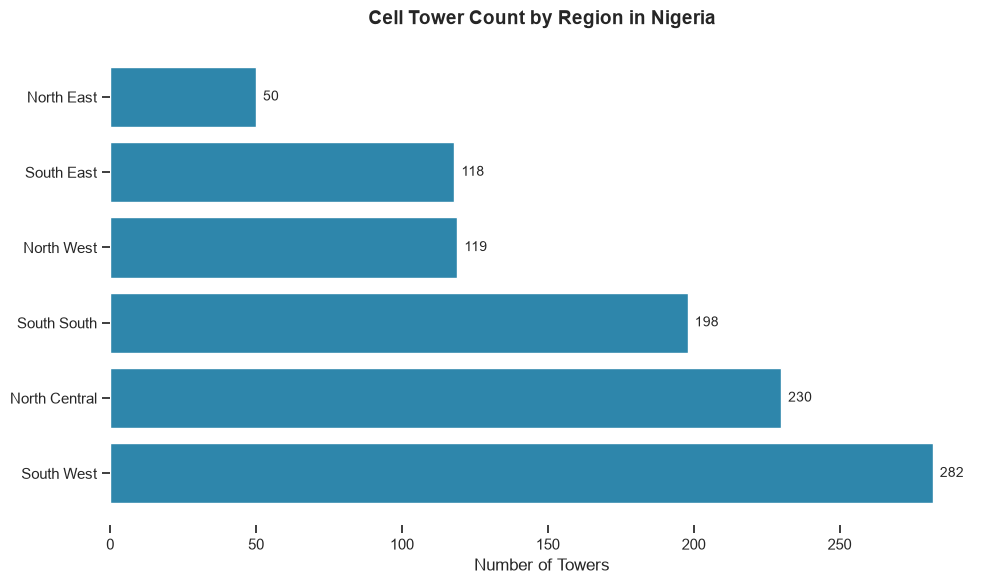

In [6]:
## despine removes border lines(spines) around the chart
### tight_layout() to avoid overlap
#### plt.show() to render everything
##### subplots(): Create multiple plots within a single figure. 

region_counts = df.groupby('region')['cell'].count().sort_values(ascending=False).reset_index()
region_counts.columns = ['region', 'tower_count']

fig, ax = plt.subplots()
bars = ax.barh(region_counts['region'], region_counts['tower_count'], color=COLORS[0])

ax.bar_label(bars, padding=5, fontsize=10)
ax.set_title('Cell Tower Count by Region in Nigeria', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Towers')
ax.set_ylabel('')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Visual 2: Towers By State

C:\Users\PC\AppData\Local\Temp\ipykernel_468\1639390078.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_counts, x='tower_count', y= 'state', palette='Blues_r', ax=ax)


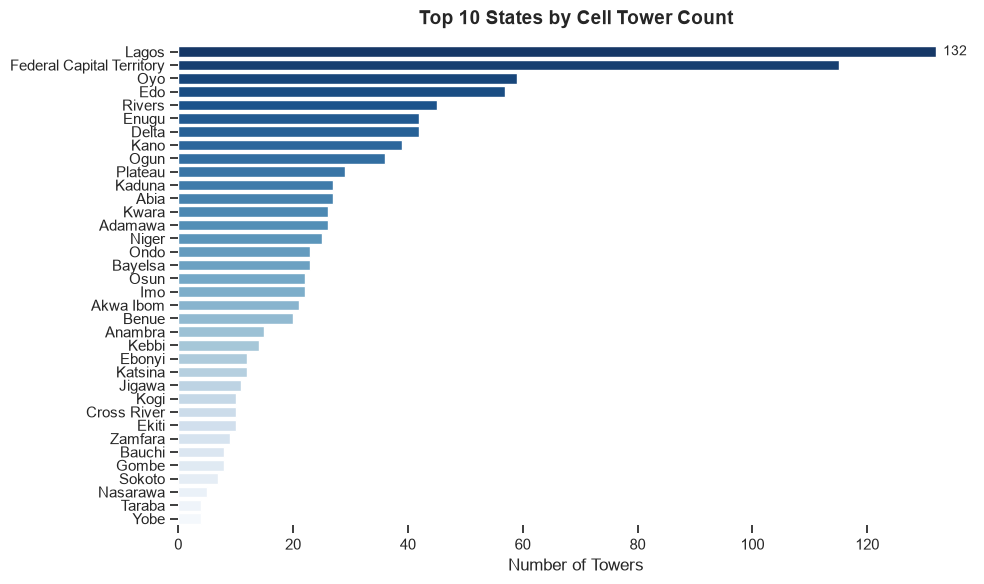

In [ ]:
state_counts = df.groupby('state')['cell'].count().sort_values(ascending=False).reset_index()
state_counts.columns = ['state', 'tower_count']

fig, ax = plt.subplots()
sns.barplot(data=state_counts, x='tower_count', y= 'state', palette='Blues_r', ax=ax)

ax.bar_label(ax.containers[0], padding=5, fontsize=10)
ax.set_title('Top 10 States by Cell Tower Count', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Towers')
ax.set_ylabel('')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Visual 3: Operator footprint by Region

C:\Users\PC\AppData\Local\Temp\ipykernel_468\1497433097.py:5: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(data=operator_region, x='region', y= 'tower_count', hue='operator', palette=COLORS, ax=ax)


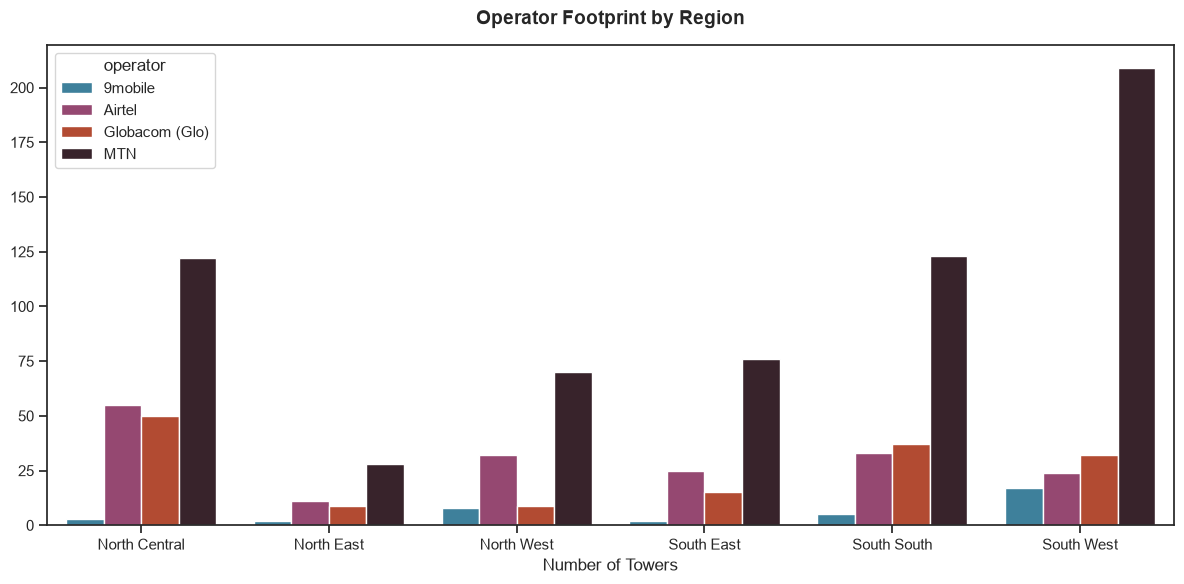

In [8]:
operator_region = df.groupby(['region', 'operator'])['cell'].count().reset_index()
operator_region.columns = ['region', 'operator', 'tower_count']

fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(data=operator_region, x='region', y= 'tower_count', hue='operator', palette=COLORS, ax=ax)

ax.set_title('Operator Footprint by Region', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Towers')
ax.set_ylabel('')
sns.despine
plt.tight_layout()
plt.show()


### Visual 4:Generation Mix by Region

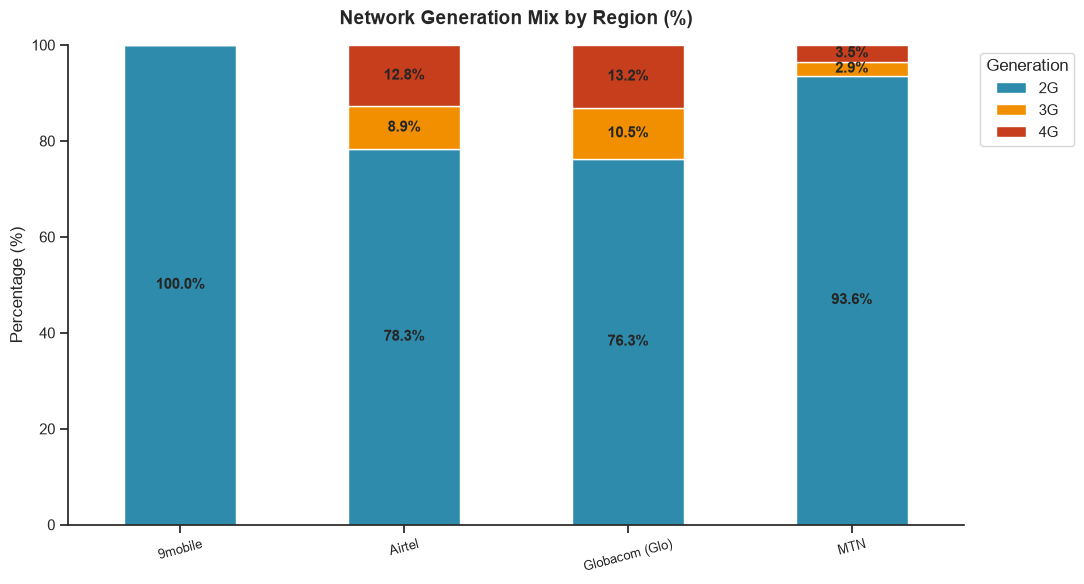

In [9]:
## fmt is a label format. %starts the format instruction
###                       .1f shows the number as a float with 1 decimal place.
####                      %% is how to print a percet sign without python thinking its another formst instruction.

gen_region = df.groupby(['operator', 'generation'])['cell'].count().unstack(fill_value=0)
gen_region_pct = gen_region.div(gen_region.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11,6))
gen_region_pct.plot(kind='bar', stacked=True, color=['#2e8bab', '#f18f01', '#c73e1d'], ax=ax)

ax.set_title('Network Generation Mix by Region (%)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('')
ax.legend(title='Generation', bbox_to_anchor=(1.01,1), loc='upper left')
ax.tick_params(axis='x', rotation=15, labelsize=9)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center',fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()


### Visual 5: Operator Vs. Generation Chart

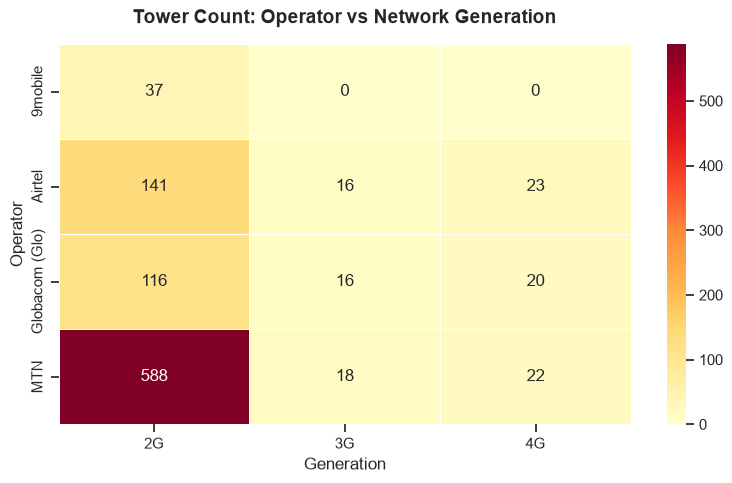

In [10]:
gen_op = df.groupby(['operator', 'generation'])['cell'].count().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(gen_op, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)

ax.set_title('Tower Count: Operator vs Network Generation', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Generation')
ax.set_ylabel('Operator')
plt.tight_layout()
plt.show()

### Recommendation and Summary
- South South ranks third in tower count, which sounds reasonable, until you look at the generation mix. 
Despite being Nigeria's economic engine, the zone runs on the same aging 2G infrastructure as everywhere else.

- South West — highest tower count (280 records) so the most reliable findings. Still overwhelmingly 2G but had the most visible 4G presence relative to its size. Lagos driving that — makes sense, it's the commercial capital and operators invest where the density and revenue is.

- North Central — second highest count (217 records). Abuja (FCT) is in here and that inflates it significantly. Similar 2G dominance but Abuja likely accounts for most of whatever 4G presence exists in the zone. Strip Abuja out and North Central probably looks much worse.

- South East - moderate count, similar 2G story. Enugu had decent representation in the sample but even there 4G was minimal.

- North West — thin on towers and thin on generations. Kano had the most records from this zone but 4G presence was negligible. L

- North East — the worst story across every metric. Fewest towers, highest average coverage range (meaning each tower is stretching furthest), and essentially zero 4G presence in the sample. Borno, Yobe, Taraba barely showed up. 

- The pattern across all regions 
2G dominance is universal.

